In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import mean_squared_error, structural_similarity

# Загрузка изображения

In [48]:

original = cv2.imread("cat.jpg", cv2.IMREAD_GRAYSCALE)

if original is None:
    raise FileNotFoundError("cat.jpg не нашёлся")


# Добавление шума (ф-ии)

In [49]:
def add_gaussian_noise(image, mean=0, sigma=30):
    # аддитивный гауссовский шум.
    image_float = image.astype(np.float32)

    noise = np.random.normal(
        loc=mean,
        scale=sigma,
        size=image.shape
    ).astype(np.float32)

    noisy = image_float + noise
    # Возвращаем значения в допустимый диапазон
    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)


def add_salt_pepper_noise(image, probability=0.02):
    """
    Добавляет импульсный шум типа соль и перец.
    probability это вероятность изменения пикселя.
    """

    result = image.copy()

    random_map = np.random.random(image.shape)

    result[random_map < probability / 2] = 0
    result[random_map > 1 - probability / 2] = 255

    return result

# Добавление шума

In [50]:
np.random.seed(42)

gaussian_noisy = add_gaussian_noise(
    original,
    mean=0,
    sigma=30
)

salt_pepper_noisy = add_salt_pepper_noise(
    original,
    probability=0.05
)

# Расчёт качества (ф-ия)

In [51]:
def calculate_metrics(reference, result):
    mse = mean_squared_error(reference, result)

    ssim = structural_similarity(
        reference,
        result,
        data_range=255
    )

    return mse, ssim


# Исходное и зашумлённое изобр.

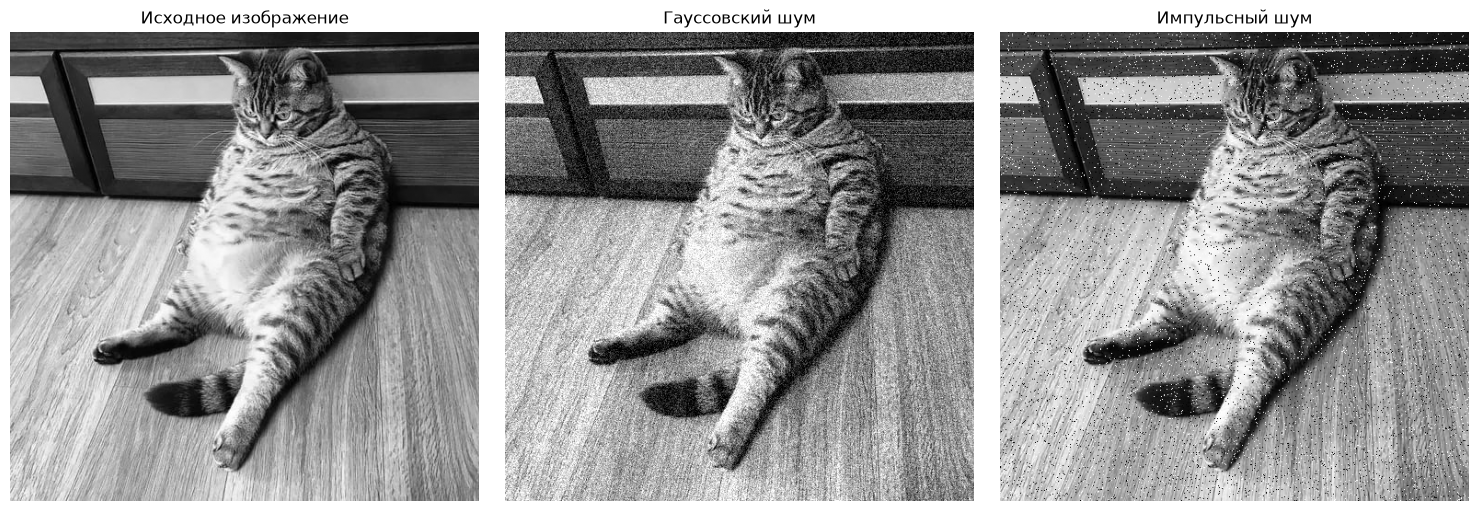

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Исходное изображение")
axes[0].axis("off")

axes[1].imshow(gaussian_noisy, cmap="gray")
axes[1].set_title("Гауссовский шум")
axes[1].axis("off")

axes[2].imshow(salt_pepper_noisy, cmap="gray")
axes[2].set_title("Импульсный шум")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# фильтры

In [53]:
def median_filter(image, kernel_size):
    return cv2.medianBlur(image, kernel_size)


def gaussian_filter(image, kernel_size, sigma):
    return cv2.GaussianBlur(
        image,
        (kernel_size, kernel_size),
        sigma
    )


def bilateral_filter(image, diameter, sigma_color, sigma_space):
    return cv2.bilateralFilter(
        image,
        diameter,
        sigma_color,
        sigma_space
    )


def nlm_filter(image, h, template_size, search_size):
    return cv2.fastNlMeansDenoising(
        image,
        None,
        h,
        template_size,
        search_size
    )

# Параметры для фильтров

In [54]:
median_parameters = [3, 5, 7]

gaussian_parameters = [
    (3, 0),
    (5, 0),
    (7, 0)
]

bilateral_parameters = [
    (5, 30, 30),
    (9, 50, 50),
    (9, 75, 75)
]

nlm_parameters = [
    (10, 7, 21),
    (20, 7, 21),
    (30, 7, 21)
]

# Применим фильтры, посмотрим результаты

In [55]:
def test_filters(noisy_image, reference, noise_name):

    results = []
    for kernel in median_parameters:
        filtered = median_filter(
           noisy_image,
            kernel
        )

        mse, ssim = calculate_metrics(
            reference,
            filtered
        )

        results.append({
            "noise": noise_name,
            "filter": "Медианный",
            "parameters": f"kernel={kernel}",
            "image": filtered,
            "mse": mse,
            "ssim": ssim
        })

    for kernel, sigma in gaussian_parameters:

        filtered = gaussian_filter(
            noisy_image,
            kernel,
            sigma
        )

        mse, ssim = calculate_metrics(
            reference,
            filtered
        )

        results.append({
            "noise": noise_name,
            "filter": "Гауссовский",
            "parameters": f"kernel={kernel}, sigma={sigma}",
            "image": filtered,
            "mse": mse,
            "ssim": ssim
        })

    for diameter, sigma_color, sigma_space in bilateral_parameters:

        filtered = bilateral_filter(
            noisy_image,
            diameter,
            sigma_color,
            sigma_space
        )

        mse, ssim = calculate_metrics(
            reference,
            filtered
        )

        results.append({
            "noise": noise_name,
            "filter": "Билатеральный",
            "parameters": (
                f"d={diameter}, "
                f"sigmaColor={sigma_color}, "
                f"sigmaSpace={sigma_space}"
            ),
            "image": filtered,
            "mse": mse,
            "ssim": ssim
        })

    for h, template_size, search_size in nlm_parameters:

        filtered = nlm_filter(
            noisy_image,
            h,
            template_size,
            search_size
        )

        mse, ssim = calculate_metrics(
            reference,
            filtered
        )

        results.append({
            "noise": noise_name,
            "filter": "NLM",
            "parameters": (
                f"h={h}, "
                f"template={template_size}, "
                f"search={search_size}"
            ),
            "image": filtered,
            "mse": mse,
            "ssim": ssim
        })

    return results

# Протестируем оба типа шумов

In [56]:
gaussian_results = test_filters(
    gaussian_noisy,
    original,
    "Гауссовский"
)

sp_results = test_filters(
    salt_pepper_noisy,
    original,
    "Импульсный"
)

all_results = gaussian_results + sp_results

# Результаты

In [57]:

for result in all_results:

    print(
        f"{result['noise']:15} | "
        f"{result['filter']:15} | "
        f"{result['parameters']:40} | "
        f"MSE = {result['mse']:.4f} | "
        f"SSIM = {result['ssim']:.4f}"
    )

Гауссовский     | Медианный       | kernel=3                                 | MSE = 294.8737 | SSIM = 0.5399
Гауссовский     | Медианный       | kernel=5                                 | MSE = 298.7039 | SSIM = 0.5071
Гауссовский     | Медианный       | kernel=7                                 | MSE = 330.4190 | SSIM = 0.4798
Гауссовский     | Гауссовский     | kernel=3, sigma=0                        | MSE = 209.1650 | SSIM = 0.6456
Гауссовский     | Гауссовский     | kernel=5, sigma=0                        | MSE = 209.6718 | SSIM = 0.6403
Гауссовский     | Гауссовский     | kernel=7, sigma=0                        | MSE = 240.0299 | SSIM = 0.6051
Гауссовский     | Билатеральный   | d=5, sigmaColor=30, sigmaSpace=30        | MSE = 391.6517 | SSIM = 0.5452
Гауссовский     | Билатеральный   | d=9, sigmaColor=50, sigmaSpace=50        | MSE = 226.8169 | SSIM = 0.6249
Гауссовский     | Билатеральный   | d=9, sigmaColor=75, sigmaSpace=75        | MSE = 224.3026 | SSIM = 0.6181
Гауссовски

# Найдем лучшие результаты

In [58]:
best_gaussian_mse = min(
    gaussian_results,
    key=lambda x: x["mse"]
)

best_gaussian_ssim = max(
    gaussian_results,
    key=lambda x: x["ssim"]
)

best_sp_mse = min(
    sp_results,
    key=lambda x: x["mse"]
)

best_sp_ssim = max(
    sp_results,
    key=lambda x: x["ssim"]
)

In [59]:
print("\nГауссовский шум:")
print(
    "По MSE:",
    best_gaussian_mse["filter"],
    best_gaussian_mse["parameters"],
    f"MSE = {best_gaussian_mse['mse']:.4f}"
)

print(
    "По SSIM:",
    best_gaussian_ssim["filter"],
    best_gaussian_ssim["parameters"],
    f"SSIM = {best_gaussian_ssim['ssim']:.4f}"
)

print("\nИмпульсный шум:")
print(
    "По MSE:",
    best_sp_mse["filter"],
    best_sp_mse["parameters"],
    f"MSE = {best_sp_mse['mse']:.4f}"
)

print(
    "По SSIM:",
    best_sp_ssim["filter"],
    best_sp_ssim["parameters"],
    f"SSIM = {best_sp_ssim['ssim']:.4f}"
)


Гауссовский шум:
По MSE: Гауссовский kernel=3, sigma=0 MSE = 209.1650
По SSIM: Гауссовский kernel=3, sigma=0 SSIM = 0.6456

Импульсный шум:
По MSE: Медианный kernel=3 MSE = 134.3501
По SSIM: Медианный kernel=3 SSIM = 0.7730


# Визуализация

## Гаусс

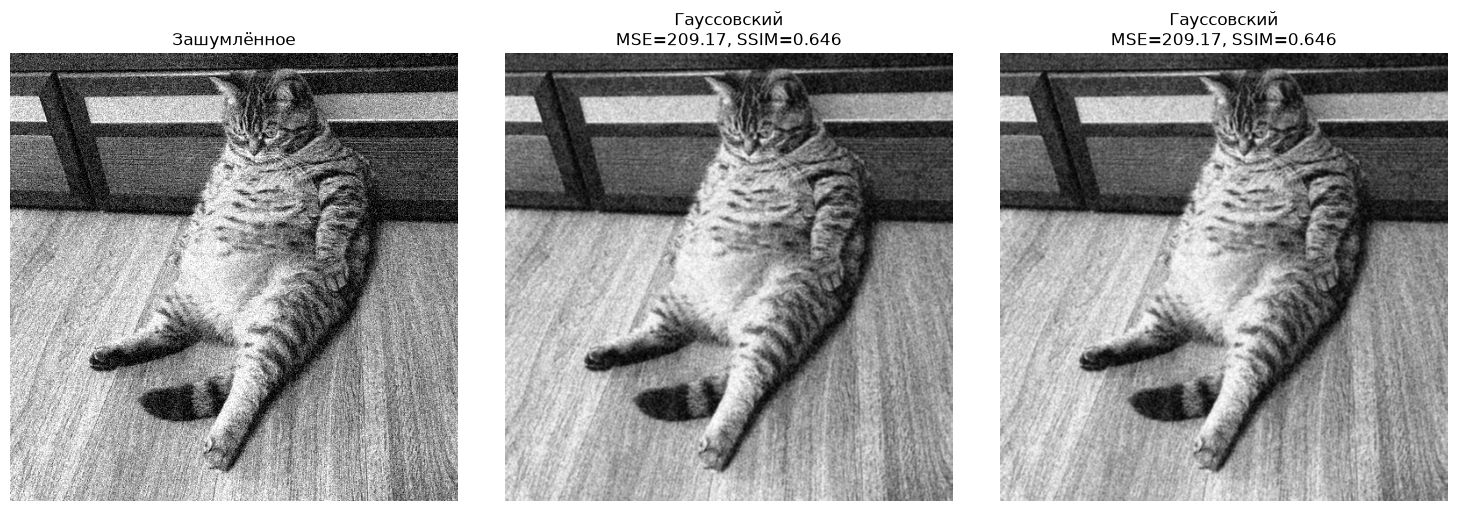

In [60]:
selected_gaussian = [
    best_gaussian_mse,
    best_gaussian_ssim
]

fig, axes = plt.subplots(
    1,
    len(selected_gaussian) + 1,
    figsize=(15, 5)
)

axes[0].imshow(gaussian_noisy, cmap="gray")
axes[0].set_title("Зашумлённое")
axes[0].axis("off")

for i, result in enumerate(selected_gaussian, start=1):

    axes[i].imshow(
        result["image"],
        cmap="gray"
    )

    axes[i].set_title(
        f"{result['filter']}\n"
        f"MSE={result['mse']:.2f}, "
        f"SSIM={result['ssim']:.3f}"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Импульс

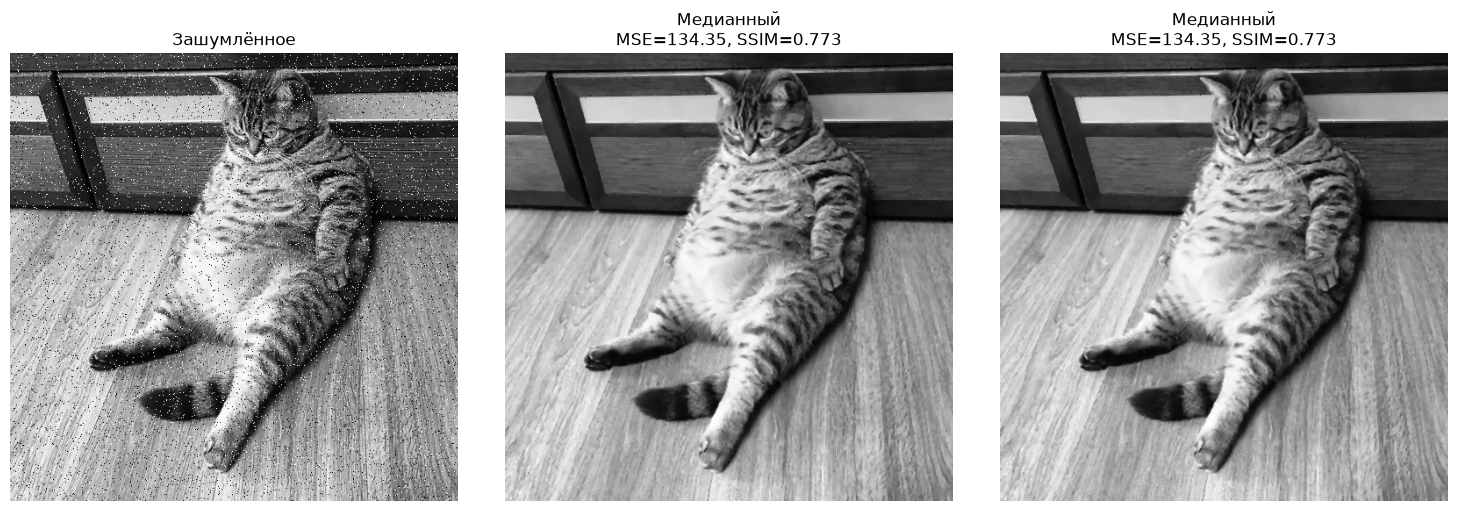

In [61]:
selected_sp = [
    best_sp_mse,
    best_sp_ssim
]

fig, axes = plt.subplots(
    1,
    len(selected_sp) + 1,
    figsize=(15, 5)
)

axes[0].imshow(
    salt_pepper_noisy,
    cmap="gray"
)

axes[0].set_title("Зашумлённое")
axes[0].axis("off")

for i, result in enumerate(selected_sp, start=1):

    axes[i].imshow(
        result["image"],
        cmap="gray"
    )

    axes[i].set_title(
        f"{result['filter']}\n"
        f"MSE={result['mse']:.2f}, "
        f"SSIM={result['ssim']:.3f}"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()